In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import matplotlib
from matplotlib import dates as mdates

matplotlib.rcParams["font.size"] = 20
matplotlib.rcParams["lines.linewidth"] = 3
matplotlib.rcParams["mathtext.default"] = 'regular'
matplotlib.rcParams['lines.markersize'] = 3

#Colour blind friendly colour palette to cycle through the different data sets
colourCycle = ['#377eb8', '#ff7f00',
               '#087E40', '#f781bf',
               "#a600ac", "#8b8b02",
               '#984ea3', "#e70004",
               '#59A9D7', '#C88147']

anticolourcycle = ['#C88147','#0080FF','#B250B5','#087E40','#59A9D7','#67B15C']


#Dictionary to label all the channels appropriately, assign them a unique colour and marker. 
# Detectors = {'Ch_4': ["LSC Left",colourCycle[0],"o"],
#              'Ch_5': ["LSC Right",colourCycle[0],"v"],
#              'Ch_8': ["NaI 1",colourCycle[2],"^"],
#              'Ch_10': ["NaI 2",colourCycle[4],"<"],
#              'Ch_12': ["NaI 3",colourCycle[6],"P"],
#              'Ch_14': ["NaI 4",colourCycle[8],"s"]
#              }

# DetectorsInv = {'Ch_4': ["LSC Left",colourCycle[1],"v"],
#                 'Ch_5': ["LSC Right",colourCycle[1],"o"],
#                 'Ch_8': ["NaI 1",colourCycle[3],">"],
#                 'Ch_10': ["NaI 2",colourCycle[5],"^"],
#                 'Ch_12': ["NaI 3",colourCycle[7],"s"],
#                 'Ch_14': ["NaI 4",colourCycle[9],"P"],}


Detectors = {'Ch_4': ["LSC Left",colourCycle[0],"o"],
             'Ch_5': ["LSC Right",colourCycle[0],"v"],
             'Ch_8': ["NaI 1",colourCycle[6],"^"],
             'Ch_10': ["NaI 2",colourCycle[6],"<"],
             'Ch_12': ["NaI 3",colourCycle[6],"P"],
             'Ch_14': ["NaI 4",colourCycle[6],"D"]
             }

DetectorsInv = {'Ch_4': ["LSC Left",colourCycle[1],"v"],
                'Ch_5': ["LSC Right",colourCycle[1],"o"],
                'Ch_8': ["NaI 1",colourCycle[7],">"],
                'Ch_10': ["NaI 2",colourCycle[7],"^"],
                'Ch_12': ["NaI 3",colourCycle[7],"D"],
                'Ch_14': ["NaI 4",colourCycle[7],"P"],}

In [11]:
################################################################################################################################
# This section of code stores the data for the K-40 background fit data in the NaI detectors.
################################################################################################################################


class k40Data:
    
    def __init__(self,ch):
        self.ch = ch
        self.data = []
        self. chLabel = r'${}^{40}$K background Fit'
        # self. chLabel = f'{Detectors[f'Ch_{self.ch}'][0]} K-40 background Fit'
        
        self.scaleFactors = []
        self.scaleFactorsErr = []
        self.dates = []
        
        self.colours = "blue"
        self.marker = Detectors[f'Ch_{self.ch}'][2]
        
        self.averageData = None
        
    def addFitResults(self,fitResults):
        self.data.append(fitResults)
        self.scaleFactors.append(fitResults.scaleFactor)
        self.scaleFactorsErr.append(fitResults.scaleFactorErr)
        self.dates.append(fitResults.date)
        
    def plotData(self,ax,NaIcolourCode = False):
        
        if (self.ch == 4 or self.ch == 5) and NaIcolourCode:
            labeledCh = []
            for i,date in enumerate(self.dates):
                colour = Detectors[f'Ch_{self.coincChannel[i]}'][1]
                if int(self.coincChannel[i]) in labeledCh:
                    ax.scatter(date,self.scaleFactors[i],color = colour, marker = self.marker,s = 50)
                else:
                    ax.scatter(date,self.scaleFactors[i],color = colour, label = Detectors[f'Ch_{self.coincChannel[i]}'][0],marker = self.marker,s = 50)
                    labeledCh.append(int(self.coincChannel[i]))
            # ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = colour, marker = self.marker,linestyle = 'None')
        else:
            ax.scatter(self.dates,self.scaleFactors,color = self.colours, marker = "X", label = self.chLabel,s = 100)
            ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = self.colours, marker = "X",linestyle = 'None')
            
class K40fitData:
    #This class is designed to be a container to hold the individual information about each channels fits. 
    
    def __init__(self,ch,scaleFactor,scaleFactorErr,date):
        self.ch = ch
        self.scaleFactor = scaleFactor
        self.scaleFactorErr = scaleFactorErr
        self.date = date
        

In [ ]:
#####################################################################################################################################3
# These classes store the data for the profile histogram fits. 


class ProfileHistData:
    # This class stores all of the data for a given detector.
    
    def __init__(self,ch):
        self.ch = ch
        self.data = []
        # self.chLabel = f"{Detectors[f'Ch_{self.ch}'][0]} 'X' Profile Hist Fit"
        # self.chLabelInv = f"{Detectors[f'Ch_{self.ch}'][0]} 'Y' Profile Hist Fit"
        
        self.chLabel = f"'X' Profile Hist Fit"
        self.chLabelInv = f"'Y' Profile Hist Fit"
        
        self.scaleFactors = []
        self.scaleFactorsErr = []
        
        self.scaleFactorsInv = []
        self.scaleFactorsErrInv = []
        
        self.dates = []
        self.coincChannel = []
        
        self.colours = Detectors[f'Ch_{self.ch}'][1]
        self.marker = Detectors[f'Ch_{self.ch}'][2]
        
        self.coloursInv = DetectorsInv[f'Ch_{self.ch}'][1]
        self.markerInv = DetectorsInv[f'Ch_{self.ch}'][2]
        
        self.averageData = None
    
    def addFitResults(self,fitResults,fitResultsInv):
        self.data.append(fitResults)
        self.scaleFactors.append(fitResults.scaleFactor)
        self.scaleFactorsErr.append(fitResults.scaleFactorErr)
        
        self.scaleFactorsInv.append(fitResultsInv.scaleFactor)
        self.scaleFactorsErrInv.append(fitResultsInv.scaleFactorErr)
        
        self.dates.append(fitResults.date)
        self.coincChannel.append(fitResults.coincCh)
        
    def AverageDailyResults(self):
        dailyData = {}
        dailyErrors = {}
        
        dailyDataInv = {}
        dailyErrorsInv = {}
        
        for i,date in enumerate(self.dates):
            currentDate = str(date)
            if currentDate in dailyData:
                dailyData[currentDate].append(self.scaleFactors[i])
                dailyErrors[currentDate].append(self.scaleFactorsErr[i])
            else:
                dailyData[currentDate] = [self.scaleFactors[i]]
                dailyErrors[currentDate] = [self.scaleFactorsErr[i]]
                
            if currentDate in dailyDataInv:
                dailyDataInv[currentDate].append(self.scaleFactorsInv[i])
                dailyErrorsInv[currentDate].append(self.scaleFactorsErrInv[i])
            else:
                dailyDataInv[currentDate] = [self.scaleFactorsInv[i]]
                dailyErrorsInv[currentDate] = [self.scaleFactorsErrInv[i]]
            
        averageDates, averageData,averageErrors,averageErrorsstd = [],[],[],[] 
        for data in dailyData:
                date = datetime.datetime.strptime(data, "%Y-%m-%d %H:%M:%S")
                averageDates.append(date)
                averageData.append(np.average(dailyData[data],weights = dailyErrors[data]))
                averageErrorsstd.append(np.std(dailyData[data]))
                error = 0
                for err in dailyErrors[data]:
                    error += err**2
                averageErrors.append(np.sqrt(error)/len(dailyErrors[data]))
                
        self.averageDates = averageDates
        self.averageData= averageData
        self.averageErrors = averageErrors
        self.averageErrorsstd = averageErrorsstd
        
        averageDatesInv, averageDataInv,averageErrorsInv,averageErrorsstdInv = [],[],[],[] 
        for data in dailyDataInv:
                date = datetime.datetime.strptime(data, "%Y-%m-%d %H:%M:%S")
                averageDatesInv.append(date)
                averageDataInv.append(np.average(dailyDataInv[data],weights = dailyErrorsInv[data]))
                averageErrorsstdInv.append(np.std(dailyDataInv[data]))
                error = 0
                for err in dailyErrorsInv[data]:
                    error += err**2
                averageErrorsInv.append(np.sqrt(error)/len(dailyErrorsInv[data]))
                
        self.averageDatesInv = averageDatesInv
        self.averageDataInv= averageDataInv
        self.averageErrorsInv = averageErrorsInv
        self.averageErrorsstdInv = averageErrorsstdInv

    def plotData(self,ax,NaIcolourCode = False):
        
        if (self.ch == 4 or self.ch == 5) and NaIcolourCode:
            labeledCh = []
            for i,date in enumerate(self.dates):
                colour = Detectors[f'Ch_{self.coincChannel[i]}'][1]
                if int(self.coincChannel[i]) in labeledCh:
                    ax.scatter(date,self.scaleFactors[i],color = colour, marker = self.marker,s = 50)
                    ax.scatter(date,self.scaleFactorsInv[i],color = self.coloursInv, marker = self.markerInv,s = 50)
                else:
                    ax.scatter(date,self.scaleFactors[i],color = colour, label = Detectors[f'Ch_{self.coincChannel[i]}'][0],marker = self.marker,s = 50)
                    ax.scatter(date,self.scaleFactorsInv[i],color = self.coloursInv, label = DetectorsInv[f'Ch_{self.coincChannel[i]}'][0],marker = self.markerInv,s = 50)
                    labeledCh.append(int(self.coincChannel[i]))
            # ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = colour, marker = self.marker,linestyle = 'None')
        else:
            ax.scatter(self.dates,self.scaleFactors,color = self.colours, marker = self.marker, label = self.chLabel,s = 100)
            ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = self.colours, marker = self.marker,linestyle = 'None')
            
            ax.scatter(self.dates,self.scaleFactorsInv,color = self.coloursInv, marker = self.markerInv, label = self.chLabelInv,s = 100)
            ax.errorbar(self.dates,self.scaleFactorsInv,yerr = self.scaleFactorsErrInv,color = self.coloursInv, marker = self.markerInv,linestyle = 'None')
        
    def plotAverageData(self,ax,plotstdev = False,plotErrProp = False):
        if self.averageData is not None:
            ax.scatter(self.averageDates,self.averageData, color = 'black', marker = self.marker, s = 100, label = 'Average')
            if plotErrProp:
                ax.errorbar(self.averageDates,self.averageData,yerr = self.averageErrors, color = 'black', marker = self.marker, linestyle = 'None', capsize = 10)
            if plotstdev:
                ax.errorbar(self.averageDates,self.averageData,yerr = self.averageErrorsstd, color = 'red', marker = self.marker, linestyle = 'None', capsize = 10, label = 'std')
                
        if self.averageDataInv is not None:
            ax.scatter(self.averageDatesInv,self.averageDataInv, color = 'black', marker = self.marker, s = 100, label = 'Average')
            if plotErrProp:
                ax.errorbar(self.averageDatesInv,self.averageDataInv,yerr = self.averageErrorsInv, color = 'black', marker = self.markerInv, linestyle = 'None', capsize = 10)
            if plotstdev:
                ax.errorbar(self.averageDatesInv,self.averageDataInv,yerr = self.averageErrorsstdInv, color = 'red', marker = self.markerInv, linestyle = 'None', capsize = 10, label = 'std')
        else:
            print('Average Data has not been computed.')
        
        
class fitData:
    #This class is designed to be a container to hold the individual information about each channels fits. 
    
    def __init__(self,ch,scaleFactor,scaleFactorErr,date,coincCh):
        self.ch = ch
        self.scaleFactor = scaleFactor
        self.scaleFactorErr = scaleFactorErr
        self.date = date
        self.coincCh = coincCh
        
    

In [13]:
def ReadInProfileData(filepath):
    #Currently only reading in all the 
    gammaEnergy = 662 #keV
    chResults,totalData = [],[] #chResults is the list of all fitData. totalData is the histogram of ProfileHistData
    chResultsInv = []
    Channels = [4,5,8,10,12,14]
    
    for ch in Channels: #initialize each ProfileHistData instance for each 
        totalData.append(ProfileHistData(ch))
        
    for file in filepath:
        try:
            with open(file) as f:
                next(f) #skips the header of the file. 
                for line in f:
                    data = line.split(",")
                    time = datetime.datetime(int(data[0].split("_")[0]),int(data[0].split("_")[1]),int(data[0].split("_")[2]))
                    channels = [int(data[1]),int(data[2])]
                    p0 = float(data[9])
                    p0Err = float(data[10])
                    p1 = float(data[11])
                    p1Err = float(data[12])
                    
                    p0Inv = float(data[16])
                    p0InvErr = float(data[17])
                    p1Inv = float(data[18])
                    p1InvErr = float(data[19])
                    

            
                    if channels[0] == 4 and channels[1] == 5:
                        continue
                    elif 0 in channels or 1 in channels:
                        continue
                    else:
                        xInt = -p0/p1
                        yInt = p0
                        
                        xIntErr = xInt*np.sqrt((p0Err/p0)**2 + (p1Err/p1)**2)
                        yIntErr = p0Err
                        
                        
                        
                        xIntInv = p0Inv
                        yIntInv = -p0Inv/p1Inv
                        
                        xIntInvErr = p0InvErr
                        yIntInvErr = yIntInv*np.sqrt((p0InvErr/p0Inv)**2 + (p1InvErr/p1Inv)**2)
                        
                        #(self,ch,scaleFactor,scaleFactorErr,date):
                        chResults.append(fitData(channels[0],xInt/662,xIntErr/662,time,channels[1])) #Save all the data in the LSC to a fitData object.
                        chResults.append(fitData(channels[1],yInt/662,yIntErr/662,time,channels[0])) #Save all the data in the NaI to a fitData object.
                        
                        chResultsInv.append(fitData(channels[0],xIntInv/662,xIntErr/662,time,channels[1]))
                        chResultsInv.append(fitData(channels[1],yIntInv/662,yIntErr/662,time,channels[0]))
                        
                        for totD in totalData: 
                            if chResults[-1].ch == totD.ch:
                                totD.addFitResults(chResults[-1],chResultsInv[-1])
                                # totD.addFitResults(chResultsInv[-1])
                                
                            if chResults[-2].ch == totD.ch:
                                totD.addFitResults(chResults[-2],chResultsInv[-2])
                                # totD.addFitResults(chResultsInv[-2])
        except:
            pass
                            
    return chResults, totalData

def readInK40Data(filepath):
    
    gammaEnergy = 1460 #keV
    chResults, totalData = [],[]
    
    Channels = [8,10,12,14]
    
    BackgroundDates = [datetime.datetime(2026,6,9),datetime.datetime(2026,6,10),datetime.datetime(2026,6,11),
                       datetime.datetime(2026,6,12),datetime.datetime(2026,6,16),datetime.datetime(2026,6,17),
                       datetime.datetime(2026,6,18),datetime.datetime(2026,6,19)]#,
                       #datetime.datetime(2026,6,24)]
    
    for ch in Channels:
        totalData.append(k40Data(ch))
        
    for file in filepath:
        
        fileData = str(file.stem).split('_')
        datestring = str(file.parent.parent.parent.parent.parent.parent.stem).split('_')
        try:
            date = datetime.datetime(int(datestring[0]),int(datestring[1]),int(datestring[2]))
        except:
            continue
        

        if 'bck' in fileData:
            if date in BackgroundDates:
                if str(Channels[0]) in fileData or str(Channels[1]) in fileData or str(Channels[2]) in fileData or str(Channels[3]) in fileData:
                
                    with open(file) as f:
                        next(f) #Skip the header
                        # print(file)
                        # print(readData)
                        
                        for line in f:

                            ch = int(fileData[-3])
                            data = line.split(",")
                            mu = float(data[5])
                            sig = float(data[4])
                            N = float(data[1])
                            
                            error = sig / np.sqrt(N)
                            
                            scaleFactor = mu / gammaEnergy
                            scaleFactorErr = error/gammaEnergy
                            
                            chResults.append(K40fitData(ch,scaleFactor,scaleFactorErr,date))
                            
                            for totD in totalData:
                                if chResults[-1].ch == totD.ch:
                                    totD.addFitResults(chResults[-1])
    return chResults,totalData


def ReadInInitData(filepath):
    with open(filepath) as f:
        for i in range(1):
            next(f) #Skip the header
            
        for line in f:
            data = line.split(',')
            LPMT = float(data[0])
            LPMTErr = float(data[1])
            
            RPMT = float(data[2])
            RPMTErr = float(data[3])
            
    return [LPMT,LPMTErr], [RPMT,RPMTErr]

In [14]:
rootFilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/') #This is the filepath to the overall directory that holds all the calibration data. 
ResultsFilePaths = rootFilePath.rglob('*_Profile_hist_fit_results_X_and_Y_Hist.txt')
K40Filepaths = rootFilePath.rglob('*_fit_results.txt')

LPMT, RPMT = ReadInInitData('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/RAW/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/figures/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2_scale_factors.txt')

K40chResults,K40totalData = readInK40Data(K40Filepaths)
chResults, totalData = ReadInProfileData(ResultsFilePaths)
for data in totalData:
    data.AverageDailyResults()


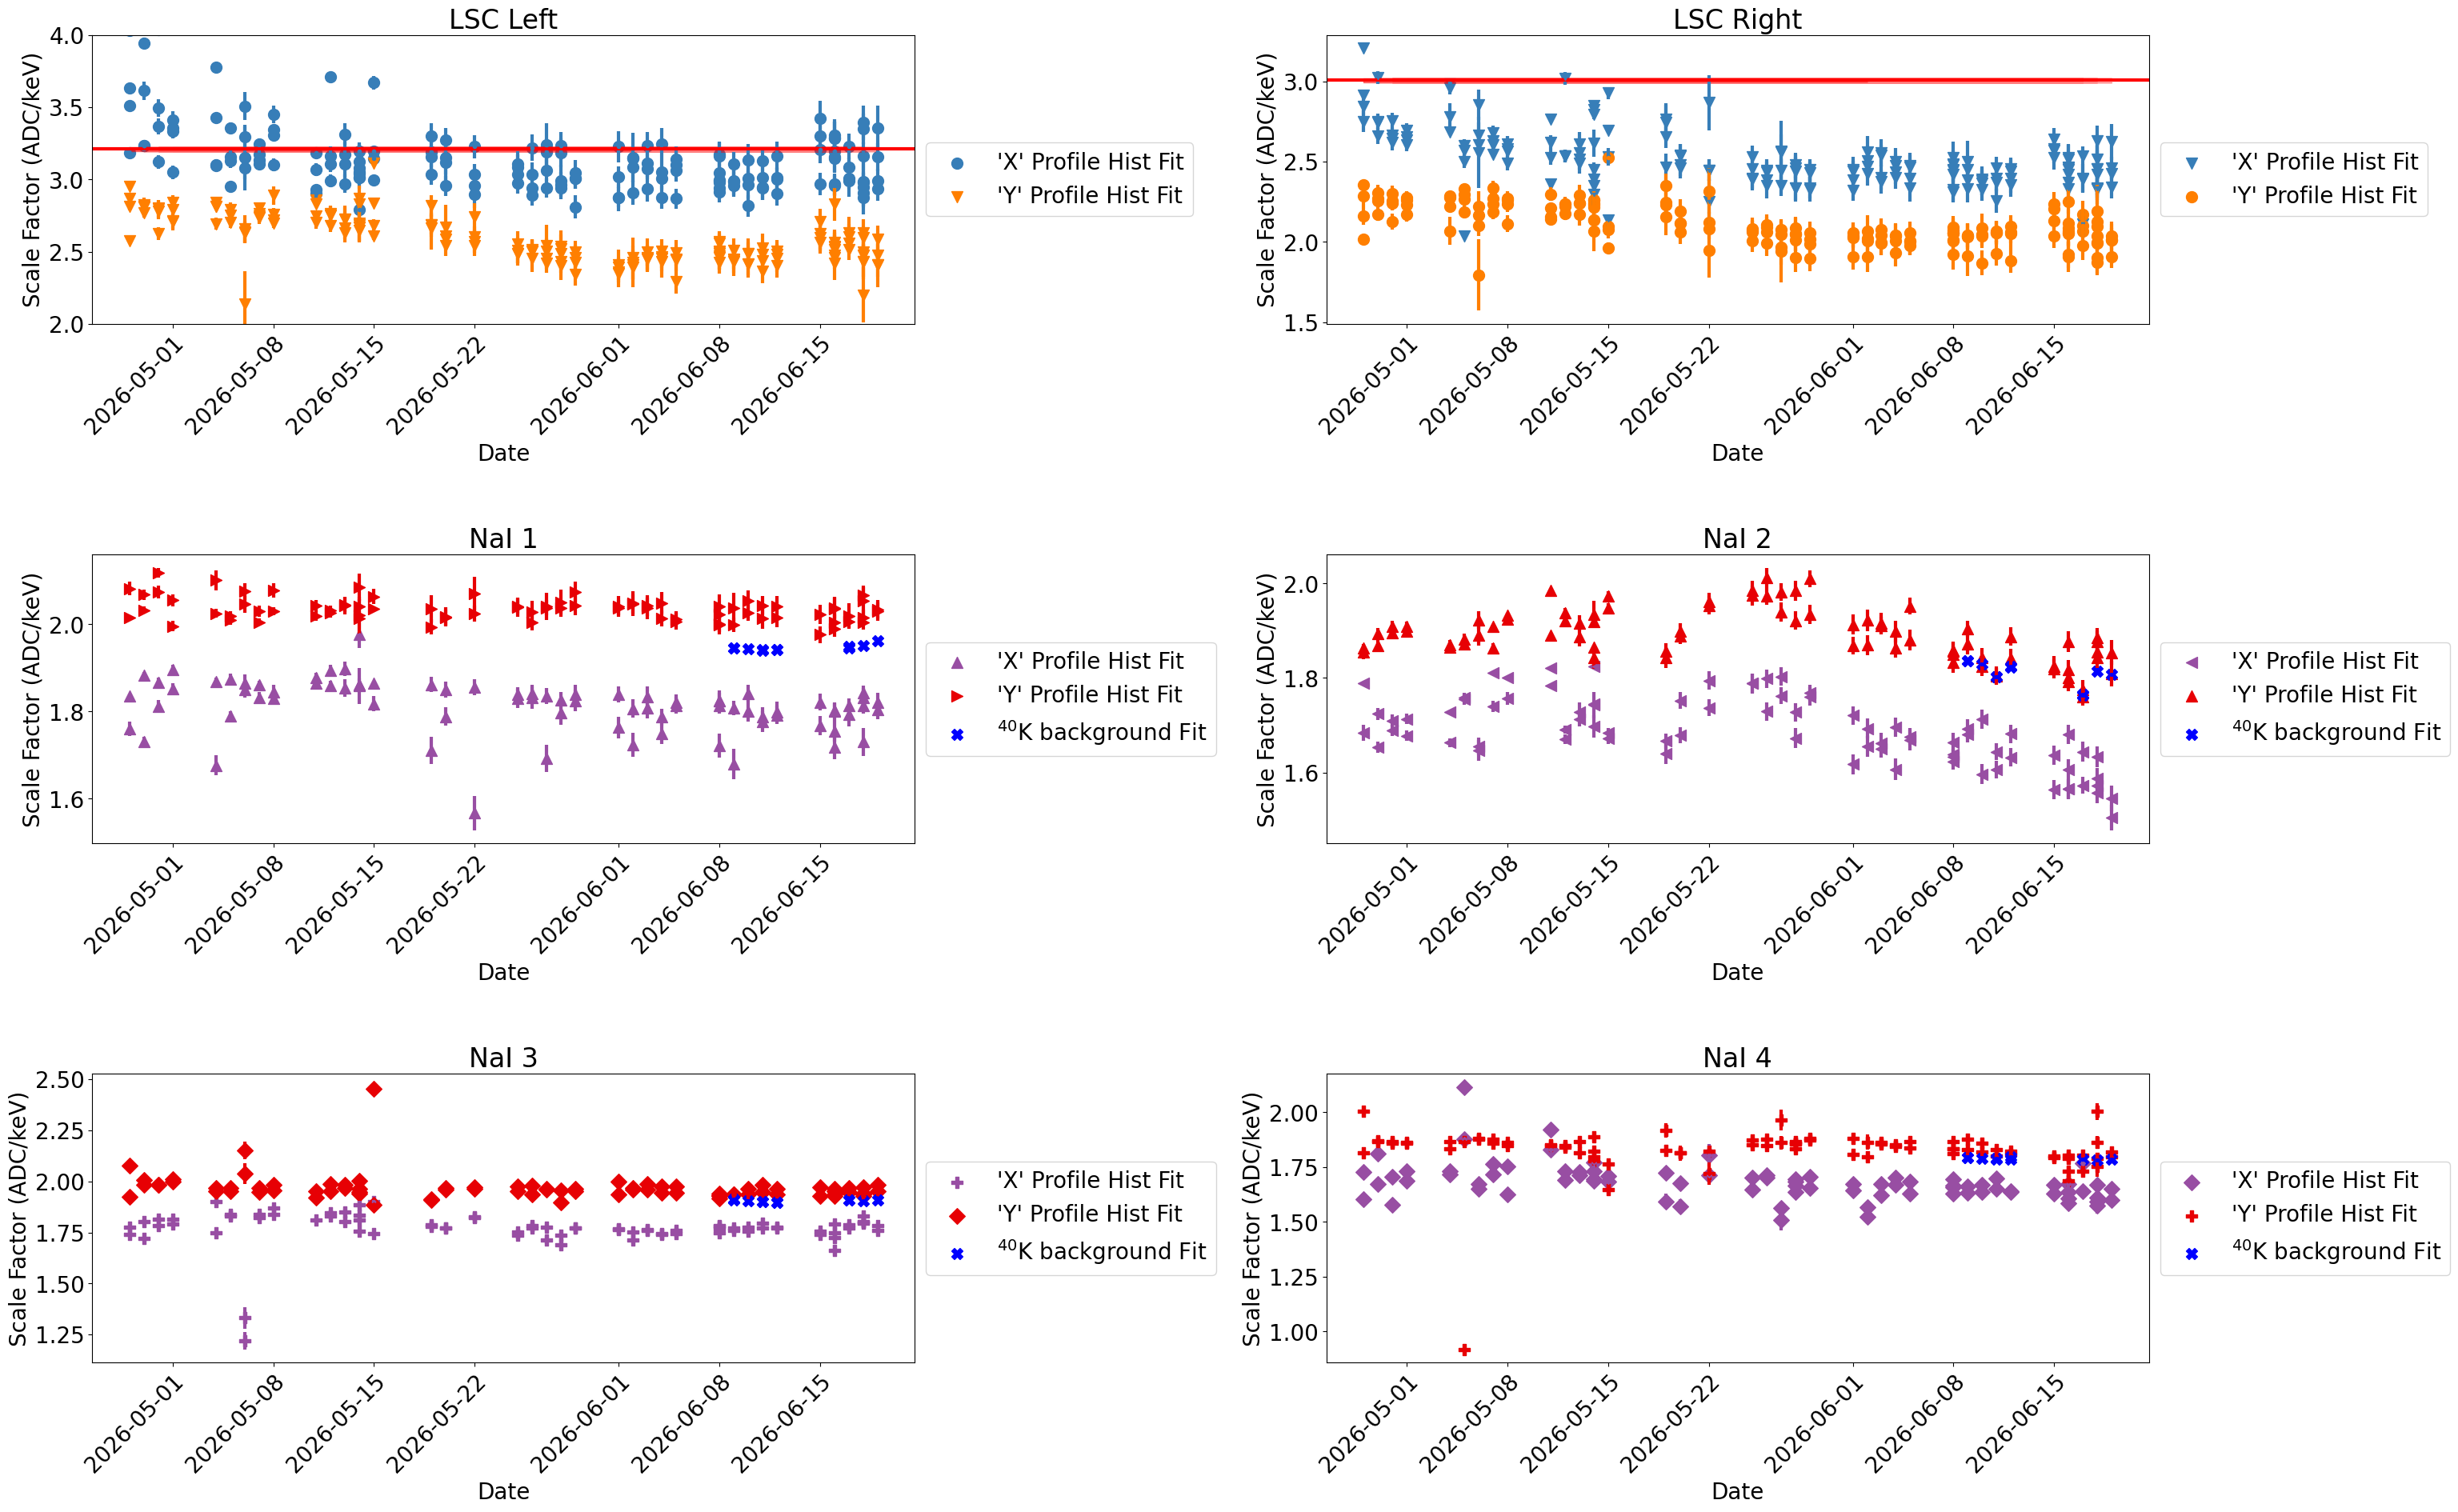

In [15]:
fig,ax = plt.subplots(3,2,figsize = (30,20))
plt.tight_layout()
plt.subplots_adjust(hspace = 0.80,wspace = 0.2,left = 0.04,bottom = 0.15)

channels = [4,5,8,10,12,14]
# axesNum = [ax[0,0],ax[0,1],ax[0,2],ax[1,0],ax[1,1],ax[1,2]]
axesNum = [ax[0,0],ax[0,1],ax[1,0],ax[1,1],ax[2,0],ax[2,1]]
for data in totalData:
    axes = axesNum[channels.index(data.ch)]        
        
    data.plotData(axes,NaIcolourCode = False)
    # data.plotAverageData(axes,plotstdev = False,plotErrProp = True)
    
for data in K40totalData:
    axes = axesNum[channels.index(data.ch)]
    
    data.plotData(axes,NaIcolourCode = False)
    
ax[0,0].axhline(LPMT[0], color = 'red')
ax[0,0].fill_between(x = totalData[0].dates,y1=LPMT[0]+LPMT[1], y2=LPMT[0]-LPMT[1], color='red',  interpolate=True, alpha=.5)

ax[0,1].axhline(RPMT[0], color = 'red')
ax[0,1].fill_between(x = totalData[0].dates,y1=RPMT[0]+RPMT[1], y2=RPMT[0]-RPMT[1], color='red',  interpolate=True, alpha=.5)
    
for i,axs in enumerate(axesNum):
    axs.set_title(f'{Detectors[f'Ch_{channels[i]}'][0]}')   
    axs.set_xlabel('Date')
    axs.set_ylabel('Scale Factor (ADC/keV)')
    box = axs.get_position()
    axs.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    
    # Format x-axis to show only YYYY-MM-DD
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    
    plt.setp(axs.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

ax[0,0].set_ylim(2,4)
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots_X_Y_profile.png', dpi = 300)
plt.savefig('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/Annulus_Stability_plots_X_Y_profile.pdf')
plt.show()

